# 🔍 이미지 유사도 검색 PoC

리테일 상품 이미지를 입력하면 **시각적으로 유사한 상품**을 찾아주는 PoC입니다.  
구글 이미지 검색, 네이버 이미지 검색과 같은 기능을 Azure AI Search로 구현합니다.

## 핵심 프로세스

```
📸 상품 이미지
    ↓
┌──────────────────────────────────────────────┐
│ 경로 1: 이미지 직접 임베딩                      │
│   이미지 → Azure AI Vision Florence → 1024D   │
│   → image_vector 인덱스 저장                   │
│                                              │
│ 경로 2: 피쳐 추출 → 텍스트 임베딩               │
│   이미지 → GPT-5.2 → 9개 피쳐 JSON            │
│   → structured_features 인덱스 저장            │
│   → 피쳐 텍스트 변환 → Azure AI Vision → 1024D │
│   → feature_text_vector 인덱스 저장            │
└──────────────────────────────────────────────┘
    ↓
🔎 신규 이미지 입력 시
    ↓
    ├─ 이미지 벡터 → image_vector 검색 (시각 유사도)
    ├─ 피쳐 텍스트 벡터 → feature_text_vector 검색 (의미 유사도)
    └─ 피쳐 텍스트 → BM25 키워드 검색
    ↓
    RRF 통합 → 유사 상품 순위 + structured_features 기반 매칭 근거
```

## 인덱스 필드 구조

| 필드 | 타입 | 차원 | 소스 | 설명 |
|------|------|------|------|------|
| `image_vector` | Vector | 1024D | 이미지 → Azure AI Vision Florence | 순수 이미지 벡터 |
| `feature_text_vector` | Vector | 1024D | 피쳐 JSON → 텍스트 → Azure AI Vision Florence | 피쳐 기반 텍스트 벡터 |
| `structured_features` | Complex | - | 이미지 → GPT-5.2 → 9개 피쳐 JSON | 매칭 근거 (판단 증거) |

---

## 1️⃣ 환경 설정

In [1]:
import os
import sys
import time
import json
import base64
import requests
import importlib
import pandas as pd
from dotenv import load_dotenv
from tqdm import tqdm
from azure.core.credentials import AzureKeyCredential
from azure.search.documents import SearchClient
from azure.search.documents.indexes import SearchIndexClient
from azure.search.documents.indexes.models import (
    SearchIndex,
    SearchField,
    SearchFieldDataType,
    SimpleField,
    SearchableField,
    VectorSearch,
    HnswAlgorithmConfiguration,
    VectorSearchProfile,
)
from azure.search.documents.models import VectorizedQuery
from openai import AzureOpenAI
from IPython.display import display, Image as IPImage

# 프로젝트 루트를 path에 추가
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ""))

# prompts 모듈 reload (파일 수정 후 커널 재시작 없이 반영)
import prompts
importlib.reload(prompts)
from prompts import (
    IMAGE_FEATURE_EXTRACTION_SYSTEM_PROMPT,
    IMAGE_FEATURE_EXTRACTION_USER_PROMPT,
    FEATURE_EXTRACTION_SCHEMA,
)

# 환경 변수 로드
load_dotenv(override=True)

# Azure AI Search 설정
SEARCH_ENDPOINT = os.getenv("SEARCH_ENDPOINT")
SEARCH_ADMIN_KEY = os.getenv("SEARCH_ADMIN_KEY")
POC_INDEX_NAME = "image-similarity-poc"

# Azure AI Vision 설정 (이미지/텍스트 직접 임베딩)
VISION_ENDPOINT = os.getenv("AZURE_AI_VISION_ENDPOINT").rstrip("/")
VISION_KEY = os.getenv("AZURE_AI_VISION_KEY")

# Azure OpenAI 설정 (GPT-5.2 피쳐 추출 + text-embedding-3-large)
OPENAI_ENDPOINT = os.getenv("AZURE_OPEN_AI_ENDPOINT")
OPENAI_KEY = os.getenv("AZURE_OPEN_AI_KEY")
CHAT_DEPLOYMENT = os.getenv("AZURE_OPENAI_CHAT_DEPLOYMENT")
EMBEDDING_DEPLOYMENT = os.getenv("AZURE_OPENAI_EMBEDDING_DEPLOYMENT")
API_VERSION = os.getenv("AZURE_OPENAI_EMBEDDING_API_VERSION")

credential = AzureKeyCredential(SEARCH_ADMIN_KEY)
index_client = SearchIndexClient(endpoint=SEARCH_ENDPOINT, credential=credential)
openai_client = AzureOpenAI(azure_endpoint=OPENAI_ENDPOINT, api_key=OPENAI_KEY, api_version=API_VERSION)

print("✅ 환경 설정 완료")
print(f"   PoC Index: {POC_INDEX_NAME}")
print(f"   Vision Endpoint: {VISION_ENDPOINT}")
print(f"   GPT Model: {CHAT_DEPLOYMENT}")
print(f"   Embedding Model: {EMBEDDING_DEPLOYMENT}")

✅ 환경 설정 완료
   PoC Index: image-similarity-poc
   Vision Endpoint: https://computer-vision-changju-v2.cognitiveservices.azure.com
   GPT Model: gpt-5.2
   Embedding Model: text-embedding-3-large


---
## 2️⃣ 신규 인덱스 생성

기존 `products-index`와 완전히 분리된 독립 인덱스를 생성합니다.

| 필드 | 타입 | 용도 |
|------|------|------|
| `id` | SimpleField (key) | 문서 키 |
| `title` | SearchableField (ko.lucene) | 제품명 (BM25 검색) |
| `brand` | SearchableField (filterable) | 브랜드 |
| `category` | SimpleField (filterable) | 카테고리 |
| `normal_price` | SimpleField (Int32) | 가격 |
| `image_link` | SimpleField | 이미지 URL |
| **`image_vector`** | **Vector (1024D)** | 이미지 직접 임베딩 |
| **`feature_text_vector`** | **Vector (1024D)** | 피쳐 텍스트 임베딩 |
| **`structured_features`** | **Complex (9 sub-fields)** | GPT-5.2 피쳐 JSON |

In [40]:
# 기존 인덱스가 있으면 삭제 후 재생성 (PoC용 — 반복 실행 가능)
existing_indexes = [idx.name for idx in index_client.list_indexes()]
if POC_INDEX_NAME in existing_indexes:
    index_client.delete_index(POC_INDEX_NAME)
    print(f"🗑️  기존 PoC 인덱스 '{POC_INDEX_NAME}' 삭제 완료")

# 필드 정의
fields = [
    SimpleField(name="id", type=SearchFieldDataType.String, key=True, filterable=True),
    SearchableField(name="title", type=SearchFieldDataType.String, analyzer_name="ko.lucene"),
    SearchableField(name="brand", type=SearchFieldDataType.String, filterable=True, analyzer_name="ko.lucene"),
    SimpleField(name="category", type=SearchFieldDataType.String, filterable=True),
    SimpleField(name="normal_price", type=SearchFieldDataType.Int32, filterable=True, sortable=True),
    SimpleField(name="image_link", type=SearchFieldDataType.String),

    # 이미지 직접 임베딩 (1024D, Azure AI Vision Florence)
    SearchField(
        name="image_vector",
        type=SearchFieldDataType.Collection(SearchFieldDataType.Single),
        searchable=True,
        vector_search_dimensions=1024,
        vector_search_profile_name="hnsw-profile",
    ),
    # 피쳐 텍스트 임베딩 — Florence (1024D, image_vector와 같은 공간)
    SearchField(
        name="feature_text_vector",
        type=SearchFieldDataType.Collection(SearchFieldDataType.Single),
        searchable=True,
        vector_search_dimensions=1024,
        vector_search_profile_name="hnsw-profile",
    ),
    # 피쳐 텍스트 임베딩 — OpenAI (3072D, text-embedding-3-large)
    SearchField(
        name="feature_text_vector_3072",
        type=SearchFieldDataType.Collection(SearchFieldDataType.Single),
        searchable=True,
        vector_search_dimensions=3072,
        vector_search_profile_name="hnsw-profile",
    ),

    # 구조화된 피쳐 (10개 sub-fields)
    SearchField(
        name="structured_features",
        type=SearchFieldDataType.ComplexType,
        fields=[
            SearchField(name="category", type=SearchFieldDataType.String, filterable=True, searchable=True),
            SearchField(name="product_type", type=SearchFieldDataType.String, filterable=True, searchable=True),
            SearchField(name="brand", type=SearchFieldDataType.String, filterable=True, searchable=True),
            SearchField(name="color", type=SearchFieldDataType.Collection(SearchFieldDataType.String), filterable=True, searchable=True),
            SearchField(name="material", type=SearchFieldDataType.Collection(SearchFieldDataType.String), filterable=True, searchable=True),
            SearchField(name="style", type=SearchFieldDataType.Collection(SearchFieldDataType.String), filterable=True, searchable=True),
            SearchField(name="mood", type=SearchFieldDataType.Collection(SearchFieldDataType.String), filterable=True, searchable=True),
            SearchField(name="pattern", type=SearchFieldDataType.String, filterable=True, searchable=True),
            SearchField(name="use_case", type=SearchFieldDataType.Collection(SearchFieldDataType.String), filterable=True, searchable=True),
            SearchField(name="target_customer", type=SearchFieldDataType.String, filterable=True, searchable=True),
        ],
    ),
]

# 벡터 검색 설정
vector_search = VectorSearch(
    algorithms=[
        HnswAlgorithmConfiguration(
            name="hnsw-config",
            parameters={"m": 4, "efConstruction": 400, "efSearch": 500, "metric": "cosine"},
        )
    ],
    profiles=[
        VectorSearchProfile(name="hnsw-profile", algorithm_configuration_name="hnsw-config"),
    ],
)

# 인덱스 생성
index = SearchIndex(name=POC_INDEX_NAME, fields=fields, vector_search=vector_search)
result = index_client.create_or_update_index(index)

print(f"\n✅ PoC 인덱스 '{POC_INDEX_NAME}' 생성 완료!")
print(f"   총 필드 수: {len(result.fields)}")
for f in result.fields:
    dim = getattr(f, 'vector_search_dimensions', None)
    if dim:
        print(f"   🔹 {f.name}: {dim}D (Vector)")
    elif f.type == "Edm.ComplexType":
        print(f"   🔹 {f.name}: Complex ({len(f.fields)} sub-fields)")

# SearchClient 생성
search_client = SearchClient(endpoint=SEARCH_ENDPOINT, index_name=POC_INDEX_NAME, credential=credential)

🗑️  기존 PoC 인덱스 'image-similarity-poc' 삭제 완료

✅ PoC 인덱스 'image-similarity-poc' 생성 완료!
   총 필드 수: 10
   🔹 image_vector: 1024D (Vector)
   🔹 feature_text_vector: 1024D (Vector)
   🔹 feature_text_vector_3072: 3072D (Vector)
   🔹 structured_features: Complex (10 sub-fields)


---
## 3️⃣ 데이터 로드 & 함수 정의

| API | 용도 | 출력 |
|-----|------|------|
| **Azure AI Vision** `vectorizeImage` | 이미지 URL → 1024D 벡터 | `image_vector` |
| **Azure AI Vision** `vectorizeText` | 텍스트 → 1024D 벡터 (Florence 공간) | `feature_text_vector` |
| **OpenAI** `text-embedding-3-large` | 텍스트 → 3072D 벡터 (텍스트 의미 공간) | `feature_text_vector_3072` |
| **GPT-5.2** (Structured Output) | 이미지 → 피쳐 JSON (선택지 기반) | `structured_features` |
| **`features_to_text()`** | 피쳐 JSON → 검색용 텍스트 변환 | 텍스트 임베딩 입력 |

In [41]:
# CSV 로드
df = pd.read_csv("../00-data/sample_data.csv")
print(f"✅ 데이터 로드: {len(df)}개 제품")
print(f"   이미지 URL 샘플: {df.iloc[0]['image_link']}")

✅ 데이터 로드: 247개 제품
   이미지 URL 샘플: https://foundryiq-image-gallery.azurewebsites.net/images/2119554205_0_600.jpg


In [3]:
# ═══════════════════════════════════════════════════════════
# A. 이미지 → 1024D 벡터 (Azure AI Vision Florence)
# ═══════════════════════════════════════════════════════════
def vectorize_image_url(image_url, max_retries=3):
    """이미지 URL → 1024D 벡터 (Azure AI Vision Florence)"""
    api_url = f"{VISION_ENDPOINT}/computervision/retrieval:vectorizeImage?api-version=2024-02-01&model-version=2023-04-15"
    headers = {"Ocp-Apim-Subscription-Key": VISION_KEY, "Content-Type": "application/json"}
    for attempt in range(max_retries):
        try:
            resp = requests.post(api_url, headers=headers, json={"url": image_url}, timeout=30)
            resp.raise_for_status()
            return resp.json().get("vector")
        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep((attempt + 1) * 2)
            else:
                print(f"❌ 이미지 임베딩 실패: {str(e)[:80]}")
                return None


# ═══════════════════════════════════════════════════════════
# B. 텍스트 → 1024D 벡터 (Azure AI Vision Florence, image_vector와 같은 공간)
# ═══════════════════════════════════════════════════════════
def vectorize_text_vision(text, max_retries=3):
    """텍스트 → 1024D 벡터 (Azure AI Vision Florence)"""
    api_url = f"{VISION_ENDPOINT}/computervision/retrieval:vectorizeText?api-version=2024-02-01&model-version=2023-04-15"
    headers = {"Ocp-Apim-Subscription-Key": VISION_KEY, "Content-Type": "application/json"}
    for attempt in range(max_retries):
        try:
            resp = requests.post(api_url, headers=headers, json={"text": text}, timeout=30)
            resp.raise_for_status()
            return resp.json().get("vector")
        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep((attempt + 1) * 2)
            else:
                print(f"❌ 텍스트 임베딩 실패: {str(e)[:80]}")
                return None


# ═══════════════════════════════════════════════════════════
# B-2. 텍스트 → 3072D 벡터 (text-embedding-3-large)
# ═══════════════════════════════════════════════════════════
def get_embedding(text):
    """텍스트 → 3072D 벡터 (text-embedding-3-large)"""
    response = openai_client.embeddings.create(input=text, model=EMBEDDING_DEPLOYMENT)
    return response.data[0].embedding


# ═══════════════════════════════════════════════════════════
# C. 이미지 → GPT-5.2 Structured Output → 피쳐 JSON
# ═══════════════════════════════════════════════════════════
def extract_structured_features(image_url, title, category, max_retries=3):
    """이미지 + 메타 → GPT-5.2 Structured Output → 피쳐 JSON (선택지 기반)"""
    user_prompt = IMAGE_FEATURE_EXTRACTION_USER_PROMPT.format(title=title, category=category)
    for attempt in range(max_retries):
        try:
            response = openai_client.chat.completions.create(
                model=CHAT_DEPLOYMENT,
                messages=[
                    {"role": "system", "content": IMAGE_FEATURE_EXTRACTION_SYSTEM_PROMPT},
                    {"role": "user", "content": [
                        {"type": "text", "text": user_prompt},
                        {"type": "image_url", "image_url": {"url": image_url, "detail": "low"}}
                    ]}
                ],
                response_format=FEATURE_EXTRACTION_SCHEMA,
            )
            return json.loads(response.choices[0].message.content)
        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep((attempt + 1) * 2)
            else:
                print(f"❌ 피쳐 추출 실패: {str(e)[:80]}")
                return None


# ═══════════════════════════════════════════════════════════
# D. 피쳐 JSON → 검색용 텍스트 변환
# ═══════════════════════════════════════════════════════════
def features_to_text(features):
    """
    structured_features JSON → 검색용 자연어 텍스트 변환
    예: "스포츠/레져, 레깅스, 블랙, 폴리에스터/스판덱스, 스포티, 활동적인, 무지, 운동/러닝, 20대여성"
    """
    if not features:
        return ""
    parts = []
    if features.get("category"):
        parts.append(features["category"])
    if features.get("product_type"):
        parts.append(features["product_type"])
    if features.get("color"):
        parts.append("/".join(features["color"]))
    if features.get("material"):
        parts.append("/".join(features["material"]))
    if features.get("style"):
        parts.append("/".join(features["style"]))
    if features.get("mood"):
        parts.append("/".join(features["mood"]))
    if features.get("pattern"):
        parts.append(features["pattern"])
    if features.get("use_case"):
        parts.append("/".join(features["use_case"]))
    if features.get("target_customer"):
        parts.append(features["target_customer"])
    if features.get("brand"):
        parts.append(features["brand"])
    return ", ".join(parts)


print("✅ 함수 정의 완료")
print("   A.   vectorize_image_url:         이미지 → 1024D (AI Vision Florence)")
print("   B.   vectorize_text_vision:       텍스트 → 1024D (AI Vision Florence)")
print("   B-2. get_embedding:               텍스트 → 3072D (text-embedding-3-large)")
print("   C.   extract_structured_features: 이미지 → 피쳐 JSON (선택지 기반, GPT-5.2)")
print("   D.   features_to_text:            피쳐 JSON → 검색용 텍스트")

✅ 함수 정의 완료
   A.   vectorize_image_url:         이미지 → 1024D (AI Vision Florence)
   B.   vectorize_text_vision:       텍스트 → 1024D (AI Vision Florence)
   B-2. get_embedding:               텍스트 → 3072D (text-embedding-3-large)
   C.   extract_structured_features: 이미지 → 피쳐 JSON (선택지 기반, GPT-5.2)
   D.   features_to_text:            피쳐 JSON → 검색용 텍스트


---
## 4️⃣ API 테스트

샘플 1개로 3개 파이프라인을 모두 검증합니다.

In [43]:
test_row = df.iloc[0]
print(f"🧪 테스트: {test_row['title'][:50]}...")
print(f"   이미지: {test_row['image_link']}")

# ── 1) image_vector 테스트 ──
print(f"\n{'─'*60}")
print("1️⃣ image_vector (이미지 → AI Vision 1024D)")
test_img_vec = vectorize_image_url(test_row['image_link'])
if test_img_vec:
    print(f"   ✅ {len(test_img_vec)}D [{test_img_vec[0]:.4f}, {test_img_vec[1]:.4f}, ...]")
else:
    print("   ❌ 실패")

# ── 2) structured_features 테스트 (선택지 기반) ──
print(f"\n{'─'*60}")
print("2️⃣ structured_features (이미지 → GPT-5.2 → 선택지 기반 JSON)")
test_features = extract_structured_features(test_row['image_link'], test_row['title'], test_row['category'])
if test_features:
    print(f"   ✅ 피쳐 추출 성공")
    for k, v in test_features.items():
        print(f"      {k}: {v}")
else:
    print("   ❌ 실패")

# ── 3) feature_text_vector 테스트 (Florence 1024D) ──
print(f"\n{'─'*60}")
print("3️⃣ feature_text_vector (피쳐 텍스트 → AI Vision Florence 1024D)")
if test_features:
    test_feature_text = features_to_text(test_features)
    print(f"   📝 피쳐 텍스트: {test_feature_text}")
    test_ft_vec = vectorize_text_vision(test_feature_text)
    if test_ft_vec:
        print(f"   ✅ {len(test_ft_vec)}D [{test_ft_vec[0]:.4f}, {test_ft_vec[1]:.4f}, ...]")
    else:
        print("   ❌ Vision 텍스트 임베딩 실패")
else:
    print("   ⚠️ 피쳐 추출 실패로 건너뜀")

# ── 4) feature_text_vector_3072 테스트 (OpenAI 3072D) ──
print(f"\n{'─'*60}")
print("4️⃣ feature_text_vector_3072 (피쳐 텍스트 → text-embedding-3-large 3072D)")
if test_features:
    test_ft_vec_3072 = get_embedding(test_feature_text)
    if test_ft_vec_3072:
        print(f"   ✅ {len(test_ft_vec_3072)}D [{test_ft_vec_3072[0]:.4f}, {test_ft_vec_3072[1]:.4f}, ...]")
    else:
        print("   ❌ OpenAI 임베딩 실패")
else:
    print("   ⚠️ 피쳐 추출 실패로 건너뜀")

🧪 테스트: 압소바6 (ATA367P2M13) 레코딸랑이세트(신생아 백일 선물)...
   이미지: https://foundryiq-image-gallery.azurewebsites.net/images/2119554205_0_600.jpg

────────────────────────────────────────────────────────────
1️⃣ image_vector (이미지 → AI Vision 1024D)
   ✅ 1024D [1.8516, 0.3186, ...]

────────────────────────────────────────────────────────────
2️⃣ structured_features (이미지 → GPT-5.2 → 선택지 기반 JSON)
   ✅ 피쳐 추출 성공
      category: 유아동
      product_type: 딸랑이세트
      brand: 압소바
      color: ['멀티컬러', '그린', '오렌지']
      material: ['플라스틱', '면혼방']
      style: ['귀여운']
      mood: ['밝은', '발랄한']
      pattern: 무지
      use_case: ['출산선물', '백일선물']
      target_customer: 신생아

────────────────────────────────────────────────────────────
3️⃣ feature_text_vector (피쳐 텍스트 → AI Vision Florence 1024D)
   📝 피쳐 텍스트: 유아동, 딸랑이세트, 멀티컬러/그린/오렌지, 플라스틱/면혼방, 귀여운, 밝은/발랄한, 무지, 출산선물/백일선물, 신생아, 압소바
   ✅ 1024D [-0.0116, 0.0240, ...]

────────────────────────────────────────────────────────────
4️⃣ feature_text_vector_3072 (피쳐 텍스트 → tex

---
## 5️⃣ 샘플 데이터 처리 (10개)

전체 247개 처리 전 10개로 빠르게 파이프라인을 검증합니다.

| Step | 처리 | 출력 |
|------|------|------|
| A | 이미지 → AI Vision → 1024D | `image_vector` |
| B | 이미지 → GPT-5.2 → JSON | `structured_features` |
| C | JSON → 텍스트 → AI Vision → 1024D | `feature_text_vector` |
| D | JSON → 텍스트 → text-embedding-3-large → 3072D | `feature_text_vector_3072` |

In [44]:
SAMPLE_SIZE = 10
df_sample = df.head(SAMPLE_SIZE).copy()
print(f"🚀 샘플 처리: {len(df_sample)}개 제품\n")

image_vectors, all_features, feature_text_vectors, feature_text_vectors_3072 = [], [], [], []

for idx, row in tqdm(df_sample.iterrows(), total=len(df_sample), desc="샘플 처리"):
    # Step A: 이미지 → 1024D
    img_vec = vectorize_image_url(row['image_link'])
    image_vectors.append(img_vec)

    # Step B: 이미지 → GPT-5.2 → 피쳐 JSON
    features = extract_structured_features(row['image_link'], row['title'], row['category'])
    all_features.append(features)

    # Step C & D: 피쳐 JSON → 텍스트 → 1024D (Florence) + 3072D (OpenAI)
    if features:
        ft_text = features_to_text(features)
        ft_vec = vectorize_text_vision(ft_text)
        ft_vec_3072 = get_embedding(ft_text)
    else:
        ft_vec = None
        ft_vec_3072 = None
    feature_text_vectors.append(ft_vec)
    feature_text_vectors_3072.append(ft_vec_3072)
    time.sleep(0.3)

df_sample['image_vector'] = image_vectors
df_sample['structured_features'] = all_features
df_sample['feature_text_vector'] = feature_text_vectors
df_sample['feature_text_vector_3072'] = feature_text_vectors_3072

img_ok = sum(1 for v in image_vectors if v is not None)
feat_ok = sum(1 for v in all_features if v is not None)
ft_ok = sum(1 for v in feature_text_vectors if v is not None)
ft3072_ok = sum(1 for v in feature_text_vectors_3072 if v is not None)

print(f"\n✅ 샘플 처리 완료")
print(f"   image_vector:              {img_ok}/{SAMPLE_SIZE}")
print(f"   structured_features:       {feat_ok}/{SAMPLE_SIZE}")
print(f"   feature_text_vector:       {ft_ok}/{SAMPLE_SIZE} (Florence 1024D)")
print(f"   feature_text_vector_3072:  {ft3072_ok}/{SAMPLE_SIZE} (OpenAI 3072D)")

🚀 샘플 처리: 10개 제품



샘플 처리: 100%|██████████| 10/10 [11:10<00:00, 67.02s/it]  


✅ 샘플 처리 완료
   image_vector:              10/10
   structured_features:       10/10
   feature_text_vector:       10/10 (Florence 1024D)
   feature_text_vector_3072:  10/10 (OpenAI 3072D)


In [45]:
# 샘플 검증: 피쳐 추출 결과 확인
print("📊 샘플 피쳐 추출 결과")
print("=" * 80)
for i in range(min(3, len(df_sample))):
    row = df_sample.iloc[i]
    feat = row['structured_features']
    print(f"\n{i+1}. {row['title'][:50]}...")
    if feat:
        print(f"   ✅ 카테고리={feat.get('category', '-')} | 유형={feat.get('product_type', '-')}")
        print(f"      컬러={feat.get('color', [])} | 재질={feat.get('material', [])}")
        print(f"      스타일={feat.get('style', [])} | 분위기={feat.get('mood', [])} | 패턴={feat.get('pattern', '-')}")
        print(f"      용도={feat.get('use_case', [])} | 타겟={feat.get('target_customer', '-')}")
        print(f"   📝 피쳐 텍스트: {features_to_text(feat)[:350]}...")
    else:
        print(f"   ❌ 추출 실패")
print("\n" + "=" * 80)

📊 샘플 피쳐 추출 결과

1. 압소바6 (ATA367P2M13) 레코딸랑이세트(신생아 백일 선물)...
   ✅ 카테고리=유아동 | 유형=딸랑이세트
      컬러=['멀티컬러', '그린', '블루'] | 재질=['플라스틱', '순면']
      스타일=['귀여운'] | 분위기=['밝은', '발랄한'] | 패턴=무지
      용도=['출산선물', '백일선물'] | 타겟=신생아
   📝 피쳐 텍스트: 유아동, 딸랑이세트, 멀티컬러/그린/블루, 플라스틱/순면, 귀여운, 밝은/발랄한, 무지, 출산선물/백일선물, 신생아, 압소바...

2. [압소바] 출산선물 티노딸랑이세트 (선물포장) (ATA367P1)...
   ✅ 카테고리=유아동 | 유형=딸랑이세트
      컬러=['화이트', '파스텔핑크', '스카이블루'] | 재질=['플라스틱', '순면']
      스타일=['귀여운'] | 분위기=['밝은', '귀여운'] | 패턴=무지
      용도=['출산선물'] | 타겟=신생아
   📝 피쳐 텍스트: 유아동, 딸랑이세트, 화이트/파스텔핑크/스카이블루, 플라스틱/순면, 귀여운, 밝은/귀여운, 무지, 출산선물, 신생아, 압소바...

3. 블루독베이비[hu] WH)블루독남아손수건SET 41170-006-01 손수건/타올/수건/1...
   ✅ 카테고리=유아동 | 유형=손수건세트
      컬러=['화이트', '블루', '옐로우'] | 재질=['순면']
      스타일=['귀여운', '내추럴'] | 분위기=['밝은', '귀여운'] | 패턴=캐릭터프린트
      용도=['출산선물', '백일선물', '일상'] | 타겟=신생아
   📝 피쳐 텍스트: 유아동, 손수건세트, 화이트/블루/옐로우, 순면, 귀여운/내추럴, 밝은/귀여운, 캐릭터프린트, 출산선물/백일선물/일상, 신생아, 블루독베이비...



---
## 6️⃣ 전체 데이터 처리 (247개)

샘플 검증이 완료되었으면 전체 데이터를 처리합니다.

> ⚠️ GPT-5.2 호출이 포함되어 있어 **약 10~15분** 소요될 수 있습니다.

In [46]:
print(f"🚀 전체 데이터 처리: {len(df)}개 제품\n")

image_vectors_all, features_all, ft_vectors_all, ft_vectors_3072_all = [], [], [], []

for idx, row in tqdm(df.iterrows(), total=len(df), desc="전체 처리"):
    # Step A: 이미지 → 1024D
    img_vec = vectorize_image_url(row['image_link'])
    image_vectors_all.append(img_vec)

    # Step B: 이미지 → GPT-5.2 → 피쳐 JSON
    features = extract_structured_features(row['image_link'], row['title'], row['category'])
    features_all.append(features)

    # Step C & D: 피쳐 JSON → 텍스트 → 1024D + 3072D
    if features:
        ft_text = features_to_text(features)
        ft_vec = vectorize_text_vision(ft_text)
        ft_vec_3072 = get_embedding(ft_text)
    else:
        ft_vec = None
        ft_vec_3072 = None
    ft_vectors_all.append(ft_vec)
    ft_vectors_3072_all.append(ft_vec_3072)
    time.sleep(0.3)

df['image_vector'] = image_vectors_all
df['structured_features'] = features_all
df['feature_text_vector'] = ft_vectors_all
df['feature_text_vector_3072'] = ft_vectors_3072_all

img_ok = sum(1 for v in image_vectors_all if v is not None)
feat_ok = sum(1 for v in features_all if v is not None)
ft_ok = sum(1 for v in ft_vectors_all if v is not None)
ft3072_ok = sum(1 for v in ft_vectors_3072_all if v is not None)

print(f"\n✅ 전체 처리 완료")
print(f"   image_vector:              {img_ok}/{len(df)}")
print(f"   structured_features:       {feat_ok}/{len(df)}")
print(f"   feature_text_vector:       {ft_ok}/{len(df)} (Florence 1024D)")
print(f"   feature_text_vector_3072:  {ft3072_ok}/{len(df)} (OpenAI 3072D)")

🚀 전체 데이터 처리: 247개 제품



전체 처리:  25%|██▌       | 62/247 [07:20<22:00,  7.14s/it]

❌ 이미지 임베딩 실패: 400 Client Error: Bad Request for url: https://computer-vision-changju-v2.cognit
❌ 피쳐 추출 실패: Error code: 400 - {'error': {'message': 'Failed to download image from https://f


전체 처리: 100%|██████████| 247/247 [31:49<00:00,  7.73s/it]


✅ 전체 처리 완료
   image_vector:              246/247
   structured_features:       246/247
   feature_text_vector:       246/247 (Florence 1024D)
   feature_text_vector_3072:  246/247 (OpenAI 3072D)


---
## 7️⃣ 인덱스 업로드

메타데이터 + 3개 벡터/피쳐 필드를 PoC 인덱스에 배치 업로드합니다.

In [47]:
# 업로드 문서 준비
documents = []
for idx, row in df.iterrows():
    doc = {
        "id": str(row['id']),
        "title": str(row['title']),
        "brand": str(row['brand']),
        "category": str(row['category']),
        "normal_price": int(row['normal_price']),
        "image_link": str(row['image_link']),
    }
    has_vector = False
    if row['image_vector'] is not None:
        doc["image_vector"] = row['image_vector']
        has_vector = True
    if row['structured_features'] is not None:
        doc["structured_features"] = row['structured_features']
    if row['feature_text_vector'] is not None:
        doc["feature_text_vector"] = row['feature_text_vector']
        has_vector = True
    if row['feature_text_vector_3072'] is not None:
        doc["feature_text_vector_3072"] = row['feature_text_vector_3072']
        has_vector = True

    if has_vector:
        documents.append(doc)

print(f"📤 업로드 준비: {len(documents)}개 문서")

# 배치 업로드
BATCH_SIZE = 500
total_success, total_failed = 0, 0

for i in tqdm(range(0, len(documents), BATCH_SIZE), desc="업로드"):
    batch = documents[i:i + BATCH_SIZE]
    try:
        result = search_client.upload_documents(documents=batch)
        total_success += sum(1 for item in result if item.succeeded)
        total_failed += sum(1 for item in result if not item.succeeded)
    except Exception as e:
        print(f"⚠️  배치 업로드 실패: {str(e)[:80]}")
        total_failed += len(batch)
    time.sleep(0.5)

print(f"\n{'='*60}")
print(f"✅ 인덱스 업로드 완료!")
print(f"   성공: {total_success}개 | 실패: {total_failed}개")
print(f"{'='*60}")

📤 업로드 준비: 246개 문서


업로드: 100%|██████████| 1/1 [00:04<00:00,  4.10s/it]


✅ 인덱스 업로드 완료!
   성공: 246개 | 실패: 0개


---
## 8️⃣ 업로드 검증

In [48]:
time.sleep(2)  # 인덱싱 반영 대기

print("🔍 업로드 검증")
print("=" * 70)

# 1) image_vector 검증 - 더미 벡터로 검색
dummy_1024 = [0.01] * 1024
results = search_client.search(
    search_text=None,
    vector_queries=[VectorizedQuery(vector=dummy_1024, k_nearest_neighbors=3, fields="image_vector")],
    select=["id", "title"],
    top=3,
)
hits = list(results)
print(f"\n1️⃣ image_vector 벡터 검색: {len(hits)}개 결과")
for h in hits[:3]:
    print(f"   ID={h['id']}: {h.get('title', 'N/A')[:40]}")
print(f"   → {'✅ 데이터 존재 확인!' if hits else '❌ 데이터 없음'}")

# 2) feature_text_vector 검증
results2 = search_client.search(
    search_text=None,
    vector_queries=[VectorizedQuery(vector=dummy_1024, k_nearest_neighbors=3, fields="feature_text_vector")],
    select=["id", "title"],
    top=3,
)
hits2 = list(results2)
print(f"\n2️⃣ feature_text_vector 벡터 검색: {len(hits2)}개 결과")
for h in hits2[:3]:
    print(f"   ID={h['id']}: {h.get('title', 'N/A')[:40]}")
print(f"   → {'✅ 데이터 존재 확인!' if hits2 else '❌ 데이터 없음'}")

# 3) structured_features 검증
doc = search_client.get_document(key=str(df.iloc[0]['id']))
sf = doc.get('structured_features')
print(f"\n3️⃣ structured_features: {'✅ ' + str(sf.get('product_type', '-')) if sf else '❌ 없음'}")
print(f"\n{'='*70}")

🔍 업로드 검증

1️⃣ image_vector 벡터 검색: 3개 결과
   ID=99: 컨버스 척테일러 올스타 클래식 블랙 M9166C
   ID=90: [나이키] DF 피트니스 티셔츠 NIKE DX0990-010
   ID=137: 컨버스 척테일러 1970s 클래식 162058C
   → ✅ 데이터 존재 확인!

2️⃣ feature_text_vector 벡터 검색: 3개 결과
   ID=155: RRL 레더 트림 트윌 토트(MARRBGS0G620035301)
   ID=34: [타미힐피거여성] 코튼 케이블 카라 스웨터 2색상 T22F6KTO003W
   ID=210: [타미힐피거여성] 엘리베이트 시크 볼캡 0AHT002WT1V18
   → ✅ 데이터 존재 확인!

3️⃣ structured_features: ✅ 딸랑이세트



---
## 9️⃣ 이미지 유사도 검색 함수

이미지를 입력하면 **4-way 하이브리드 검색**으로 유사 상품을 찾고, 피쳐 비교 근거를 보여줍니다.

```
📸 신규 이미지
    ↓
    ├─ 경로 1: 이미지 → AI Vision → 1024D → image_vector 검색 (시각 유사도)
    ├─ 경로 2: 이미지 → GPT-5.2 → 피쳐 텍스트 → AI Vision → 1024D → feature_text_vector 검색 (시각-의미 크로스모달)
    ├─ 경로 3: 피쳐 텍스트 → text-embedding-3-large → 3072D → feature_text_vector_3072 검색 (텍스트 의미)
    └─ 경로 4: 피쳐 텍스트 → BM25 키워드 검색 (키워드 매칭)
    ↓
    RRF 통합 → 이미지 그리드 + 피쳐 비교 테이블 (판단 근거)
```

In [4]:
from IPython.display import HTML


# ─────────────────────────────────────────────
# 이미지 URL → base64 data URI 변환
# GitHub에서 외부 이미지 URL이 CSP로 차단되므로,
# 이미지를 다운로드하여 base64로 인라인 임베딩합니다.
# ─────────────────────────────────────────────
_b64_cache = {}

def image_url_to_base64(url):
    """이미지 URL → base64 data URI (GitHub 렌더링 호환)"""
    if url in _b64_cache:
        return _b64_cache[url]
    try:
        resp = requests.get(url, timeout=10)
        resp.raise_for_status()
        content_type = resp.headers.get("content-type", "image/jpeg").split(";")[0].strip()
        b64 = base64.b64encode(resp.content).decode()
        data_uri = f"data:{content_type};base64,{b64}"
        _b64_cache[url] = data_uri
        return data_uri
    except Exception:
        return url  # 실패 시 원본 URL 반환


# ─────────────────────────────────────────────
# 이미지 그리드 표시 (구글 이미지 검색 스타일)
# ─────────────────────────────────────────────
def display_image_grid(query_image_url, results, title="검색 결과"):
    """입력 이미지와 결과 이미지를 구글 이미지 검색처럼 그리드로 표시"""
    query_b64 = image_url_to_base64(query_image_url)
    html = f"""
    <div style="margin:10px 0;">
      <h3 style="color:#1a73e8;">{title}</h3>
      <div style="display:flex; align-items:flex-start; gap:20px; margin-bottom:15px;">
        <div style="flex-shrink:0; text-align:center;">
          <div style="font-size:12px; color:#666; margin-bottom:5px;">📸 입력 이미지</div>
          <img src="{query_b64}" style="width:180px; height:180px; object-fit:contain; border:3px solid #1a73e8; border-radius:8px; background:#f8f9fa;">
        </div>
        <div style="flex-shrink:0; font-size:24px; align-self:center; color:#999;">→</div>
        <div style="display:flex; gap:12px; flex-wrap:wrap;">
    """
    for idx, r in enumerate(results, 1):
        img = r.get('image_link', '')
        img_b64 = image_url_to_base64(img)
        rtitle = r.get('title', 'N/A')[:25]
        score = r.get('@search.score', 0)
        price = r.get('normal_price', 0)
        html += f"""
          <div style="text-align:center; width:140px;">
            <img src="{img_b64}" style="width:130px; height:130px; object-fit:contain; border:1px solid #ddd; border-radius:6px; background:#fff; cursor:pointer;"
                 title="{r.get('title', '')}">
            <div style="font-size:11px; color:#333; margin-top:4px; overflow:hidden; text-overflow:ellipsis; white-space:nowrap;">{rtitle}</div>
            <div style="font-size:10px; color:#999;">#{idx} score:{score:.3f}</div>
            <div style="font-size:11px; color:#1a73e8; font-weight:bold;">{price:,}원</div>
          </div>
        """
    html += "</div></div></div>"
    display(HTML(html))


# ─────────────────────────────────────────────
# 피쳐 비교 테이블 (판단 근거)
# ─────────────────────────────────────────────
def display_feature_comparison(query_features, results):
    """입력 이미지 피쳐와 결과 이미지 피쳐를 나란히 비교하는 HTML 테이블"""
    if not query_features:
        return

    feature_keys = [
        ("category", "카테고리"),
        ("product_type", "제품유형"),
        ("color", "컬러"),
        ("material", "재질"),
        ("style", "스타일"),
        ("mood", "분위기"),
        ("pattern", "패턴"),
        ("use_case", "용도"),
        ("target_customer", "타겟"),
        ("brand", "브랜드"),
    ]

    html = """
    <div style="margin:15px 0;">
      <h3 style="color:#1a73e8;">📋 피쳐 비교 근거 (왜 유사한가?)</h3>
      <div style="overflow-x:auto;">
      <table style="border-collapse:collapse; font-size:12px; width:100%;">
        <tr style="background:#1a73e8; color:white;">
          <th style="padding:8px; border:1px solid #ccc; min-width:80px;">피쳐</th>
          <th style="padding:8px; border:1px solid #ccc; min-width:120px;">🔍 입력 이미지</th>
    """
    result_list = list(results) if not isinstance(results, list) else results
    for idx, r in enumerate(result_list[:5], 1):
        rtitle = r.get('title', 'N/A')[:18]
        html += f'<th style="padding:8px; border:1px solid #ccc; min-width:100px;">#{idx} {rtitle}</th>'
    html += "</tr>"

    for fkey, flabel in feature_keys:
        html += f'<tr><td style="padding:6px 8px; border:1px solid #ddd; font-weight:bold; background:#f8f9fa;">{flabel}</td>'

        q_val = query_features.get(fkey)
        q_str = ", ".join(q_val) if isinstance(q_val, list) else (q_val or "-")
        html += f'<td style="padding:6px 8px; border:1px solid #ddd; background:#e8f0fe;">{q_str}</td>'

        for r in result_list[:5]:
            sf = r.get('structured_features', {}) or {}
            r_val = sf.get(fkey)
            r_str = ", ".join(r_val) if isinstance(r_val, list) else (r_val or "-")

            match = False
            if q_val and r_val:
                if isinstance(q_val, list) and isinstance(r_val, list):
                    match = bool(set(q_val) & set(r_val))
                else:
                    match = q_val == r_val

            bg = "#d4edda" if match else "#fff"
            icon = " ✅" if match else ""
            html += f'<td style="padding:6px 8px; border:1px solid #ddd; background:{bg};">{r_str}{icon}</td>'
        html += "</tr>"

    html += "</table></div></div>"
    display(HTML(html))


# ─────────────────────────────────────────────
# 이미지 유사도 검색 (4-way 하이브리드)
# 이미지벡터(1024D) + 피쳐텍스트Florence(1024D) + 피쳐텍스트OpenAI(3072D) + BM25
# ─────────────────────────────────────────────
CANDIDATE_POOL = 20

def search_similar_images(image_url, top_k=5):
    """
    이미지 유사도 검색 — 4-way 하이브리드

    1) 이미지 → AI Vision → 1024D → image_vector (시각 유사도)
    2) 피쳐 텍스트 → AI Vision → 1024D → feature_text_vector (시각-의미 크로스모달)
    3) 피쳐 텍스트 → text-embedding-3-large → 3072D → feature_text_vector_3072 (텍스트 의미)
    4) 피쳐 텍스트 → BM25 키워드 검색
    → RRF 통합 + 피쳐 비교 근거 테이블
    """
    # ── 경로 1: 이미지 직접 벡터화 ──
    print("🔹 이미지 벡터화 중 (AI Vision → 1024D)...")
    image_vec = vectorize_image_url(image_url)
    if image_vec is None:
        print("❌ 이미지 벡터화 실패")
        return []

    # ── 경로 2 & 3: 피쳐 추출 → 텍스트 벡터화 (Florence 1024D + OpenAI 3072D) ──
    print("🔹 GPT-5.2 피쳐 추출 중 (선택지 기반)...")
    query_features = extract_structured_features(image_url, "검색 쿼리 이미지", "")

    vector_queries = [
        VectorizedQuery(
            vector=image_vec,
            k_nearest_neighbors=CANDIDATE_POOL,
            fields="image_vector",
            weight=1.5,
        ),
    ]
    search_text = None

    if query_features:
        feature_text = features_to_text(query_features)
        print(f"   📝 추출 피쳐: {feature_text[:80]}...")

        # Florence 1024D (image_vector와 같은 공간)
        print("🔹 피쳐 텍스트 → Florence 1024D...")
        ft_vec = vectorize_text_vision(feature_text)
        if ft_vec:
            vector_queries.append(
                VectorizedQuery(
                    vector=ft_vec,
                    k_nearest_neighbors=CANDIDATE_POOL,
                    fields="feature_text_vector",
                    weight=1.0,
                )
            )

        # OpenAI 3072D (텍스트 의미 특화)
        print("🔹 피쳐 텍스트 → text-embedding-3-large 3072D...")
        ft_vec_3072 = get_embedding(feature_text)
        if ft_vec_3072:
            vector_queries.append(
                VectorizedQuery(
                    vector=ft_vec_3072,
                    k_nearest_neighbors=CANDIDATE_POOL,
                    fields="feature_text_vector_3072",
                    weight=1.0,
                )
            )

        search_text = feature_text
    else:
        print("   ⚠️ 피쳐 추출 실패 — 이미지 벡터 검색만 수행합니다")

    # ── 4-way 하이브리드 검색 ──
    print(f"🔀 하이브리드 검색 실행 (벡터 {len(vector_queries)}개×{CANDIDATE_POOL}후보 + {'BM25' if search_text else '벡터만'} → top {top_k})...")
    results = search_client.search(
        search_text=search_text,
        vector_queries=vector_queries,
        select=["id", "title", "brand", "category", "normal_price", "image_link", "structured_features"],
        top=top_k,
    )
    result_list = list(results)

    # ── 결과 표시 ──
    display_image_grid(image_url, result_list,
                       f"🔍 유사 상품 검색 결과 (4-way 하이브리드: 이미지 + Florence + OpenAI + BM25)")

    if query_features and result_list:
        display_feature_comparison(query_features, result_list)

    return result_list


print("✅ 검색 함수 정의 완료")
print(f"   CANDIDATE_POOL={CANDIDATE_POOL}")
print("   4-way 하이브리드: image_vector(1024D) + feature_text_vector(1024D) + feature_text_vector_3072(3072D) + BM25")

✅ 검색 함수 정의 완료
   CANDIDATE_POOL=20
   4-way 하이브리드: image_vector(1024D) + feature_text_vector(1024D) + feature_text_vector_3072(3072D) + BM25


---
## 🔟 데모: 이미지 유사도 검색

이미지를 입력하면 **3-way 하이브리드 검색** 결과가 이미지 그리드 + 피쳐 비교 테이블로 표시됩니다.

### 데모 1: 🏃 스포츠 상품 (레깅스)

In [5]:
# 데모 1: 스포츠 레깅스 이미지 → 유사 상품 검색
sport_url = "https://foundryiq-image-gallery.azurewebsites.net/images/2210550987_0_600.jpg"
results_sport = search_similar_images(sport_url, top_k=5)

🔹 이미지 벡터화 중 (AI Vision → 1024D)...
❌ 이미지 임베딩 실패: 403 Client Error: Forbidden for url: https://computer-vision-changju-v2.cognitiv
❌ 이미지 벡터화 실패


### 데모 2: 👶 유아동 상품 (손수건 세트)

🔹 이미지 벡터화 중 (AI Vision → 1024D)...
🔹 GPT-5.2 피쳐 추출 중 (선택지 기반)...
   📝 추출 피쳐: 유아동, 손수건세트, 화이트/스카이블루/옐로우, 순면, 귀여운/내추럴, 밝은/귀여운, 캐릭터프린트, 출산선물/백일선물/일상, 신생아, BLUED...
🔹 피쳐 텍스트 → Florence 1024D...
🔹 피쳐 텍스트 → text-embedding-3-large 3072D...
🔀 하이브리드 검색 실행 (벡터 3개×20후보 + BM25 → top 5)...



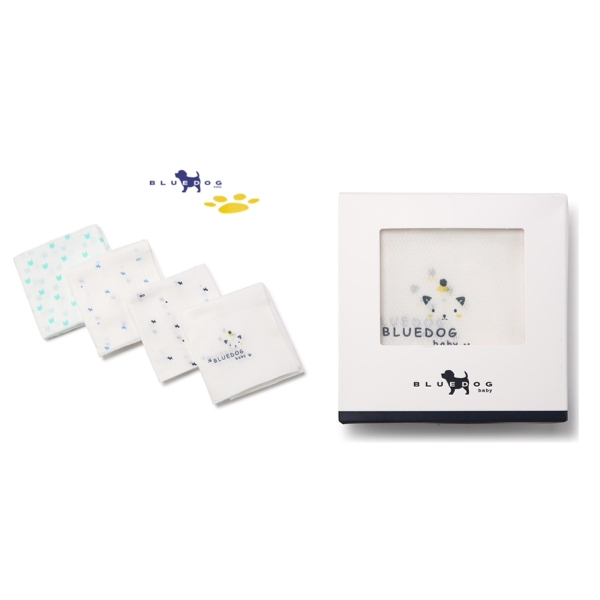
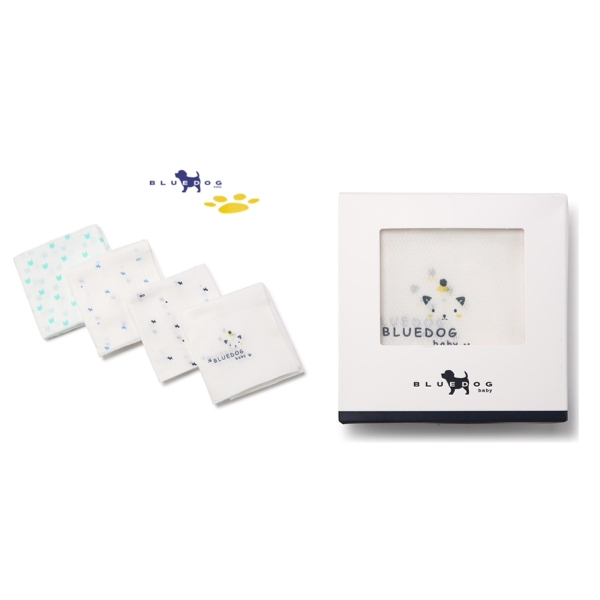
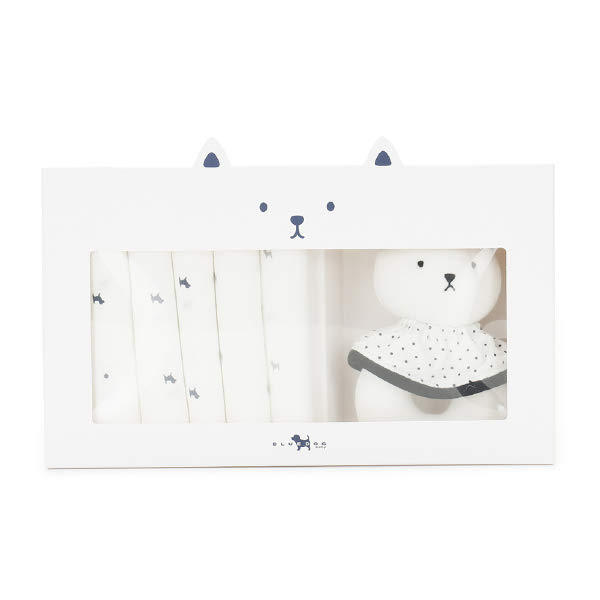
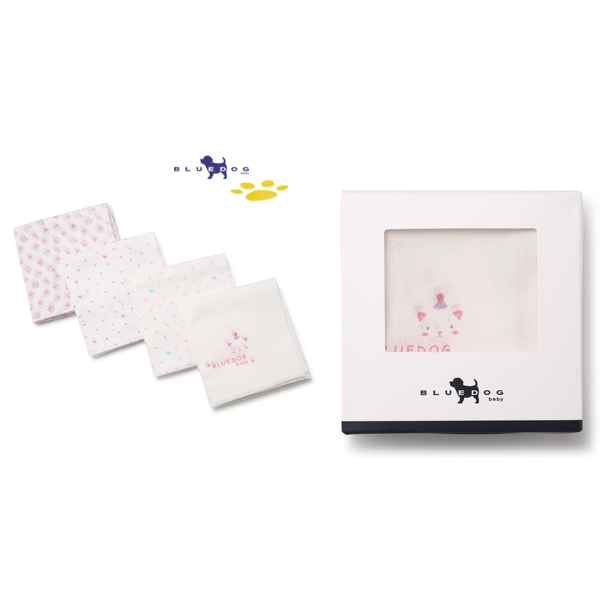
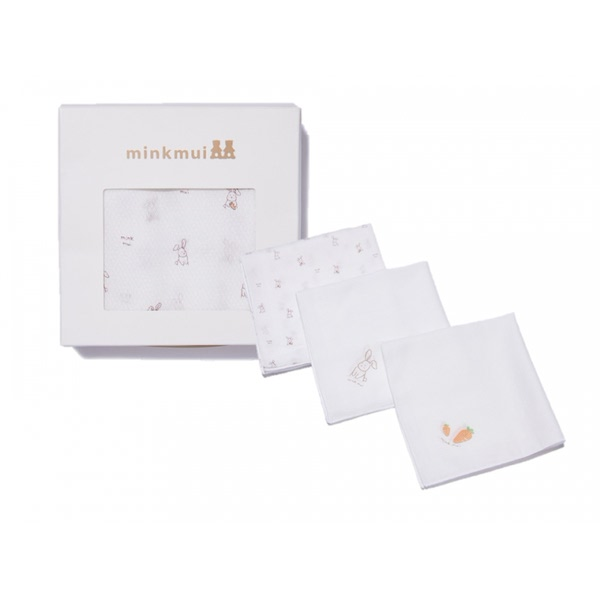
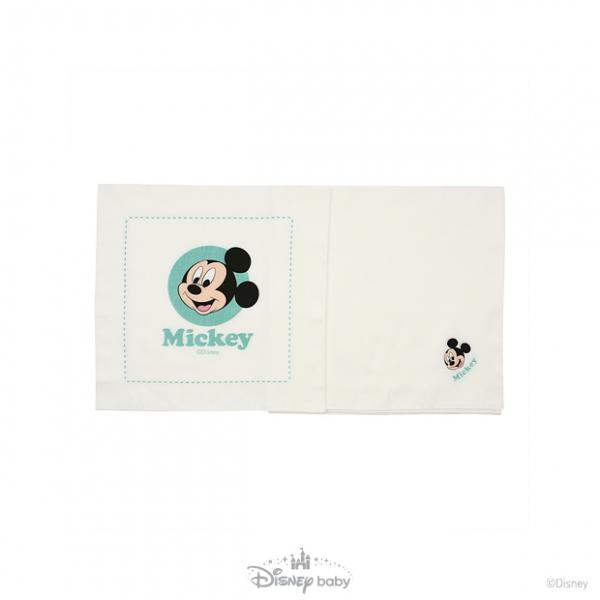

피쳐,🔍 입력 이미지,#1 블루독베이비[hu] WH)블루독남,#2 [B블루독베이비B] (WH)도기딸,#3 블루독베이비[hu] PK)블루독뱀,#4 [M밍크뮤D] (WH)루루뱀부손수,#5 아가방 미키프렌즈손수건세트(10P
카테고리,유아동,유아동 ✅,유아동 ✅,유아동 ✅,유아동 ✅,유아동 ✅
제품유형,손수건세트,손수건세트 ✅,손수건세트 ✅,손수건세트 ✅,손수건세트 ✅,손수건세트 ✅
컬러,"화이트, 스카이블루, 옐로우","화이트, 블루, 옐로우 ✅","화이트, 그레이 ✅","화이트, 핑크 ✅","화이트, 아이보리 ✅","아이보리, 블랙, 스카이블루 ✅"
재질,순면,순면 ✅,순면 ✅,뱀부,뱀부,순면 ✅
스타일,"귀여운, 내추럴","귀여운, 내추럴 ✅","귀여운, 미니멀 ✅","귀여운, 내추럴 ✅","귀여운, 내추럴 ✅",귀여운 ✅
분위기,"밝은, 귀여운","밝은, 귀여운 ✅","심플한, 귀여운 ✅","밝은, 귀여운 ✅","밝은, 귀여운 ✅","귀여운, 밝은 ✅"
패턴,캐릭터프린트,캐릭터프린트 ✅,캐릭터프린트 ✅,캐릭터프린트 ✅,캐릭터프린트 ✅,캐릭터프린트 ✅
용도,"출산선물, 백일선물, 일상","출산선물, 백일선물, 일상 ✅","출산선물, 백일선물, 돌선물 ✅","출산선물, 백일선물, 일상 ✅","출산선물, 백일선물, 일상 ✅","일상, 출산선물, 백일선물 ✅"
타겟,신생아,신생아 ✅,신생아 ✅,신생아 ✅,신생아 ✅,영유아
브랜드,BLUEDOG,블루독베이비,블루독베이비,블루독베이비,밍크뮤,아가방


In [51]:
# 데모 2: 유아동 손수건 세트 이미지 → 유사 상품 검색
baby_url = "https://foundryiq-image-gallery.azurewebsites.net/images/2138687276_0_600.jpg"
results_baby = search_similar_images(baby_url, top_k=5)

### 데모 3: 👜 패션 상품 (백팩)

🔹 이미지 벡터화 중 (AI Vision → 1024D)...
🔹 GPT-5.2 피쳐 추출 중 (선택지 기반)...
   📝 추출 피쳐: 패션잡화, 백팩, 블랙, 나일론, 스트릿/캐주얼, 세련된/활동적인, 무지, 일상/외출/통학, 유니섹스...
🔹 피쳐 텍스트 → Florence 1024D...
🔹 피쳐 텍스트 → text-embedding-3-large 3072D...
🔀 하이브리드 검색 실행 (벡터 3개×20후보 + BM25 → top 5)...



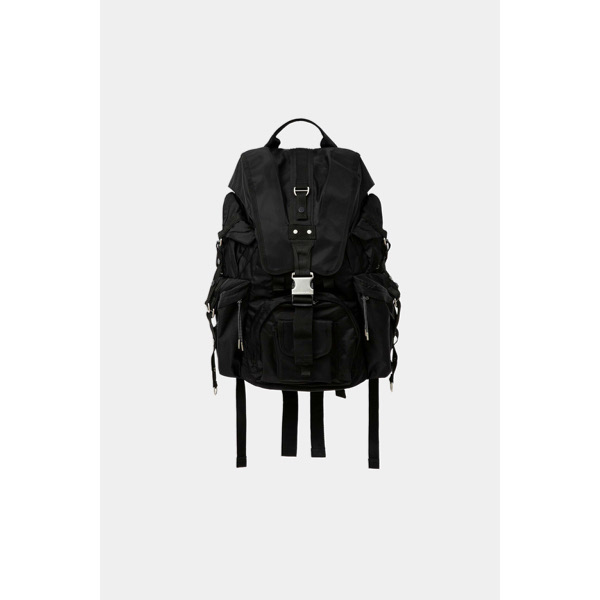
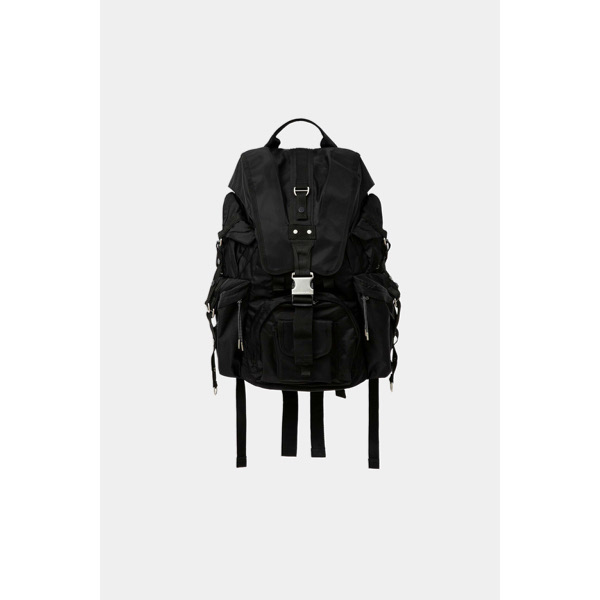
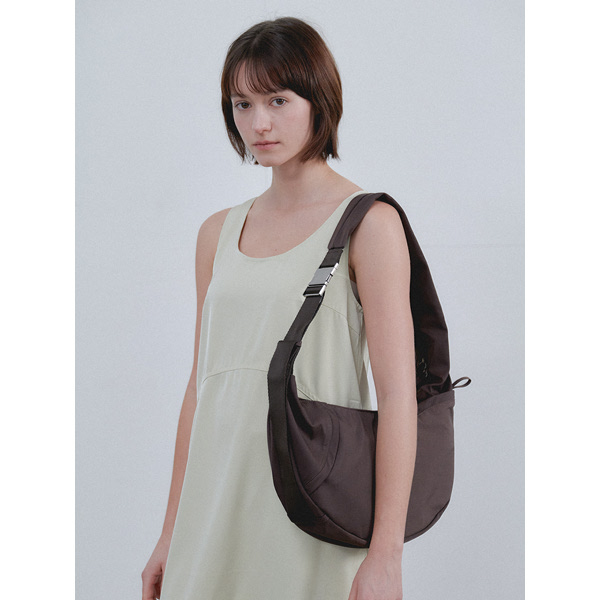
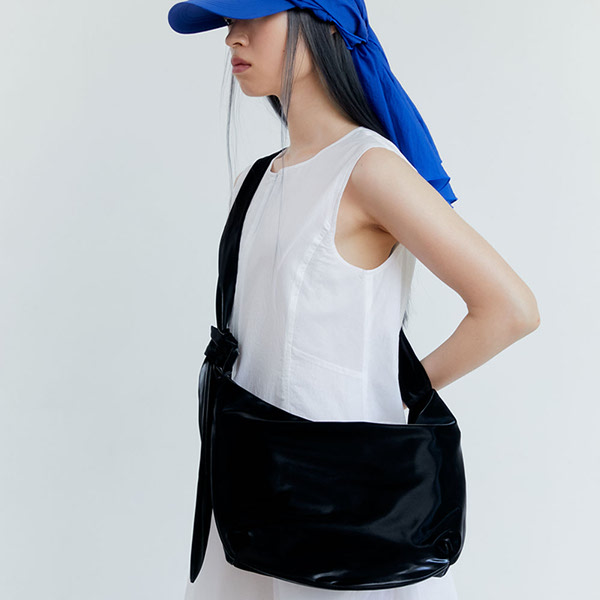
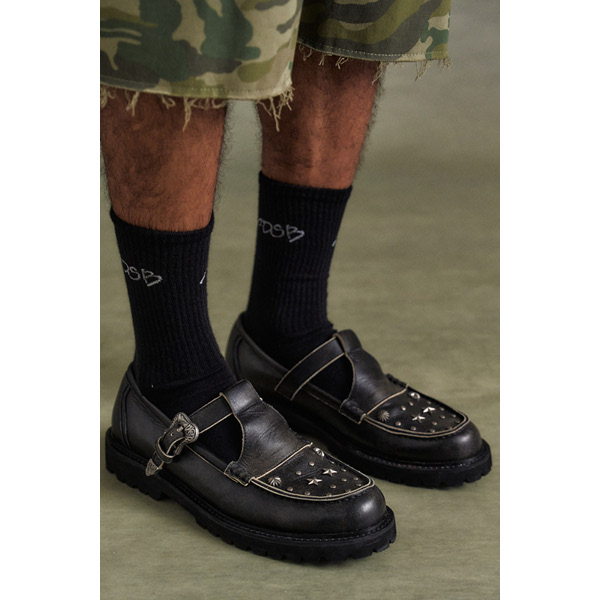
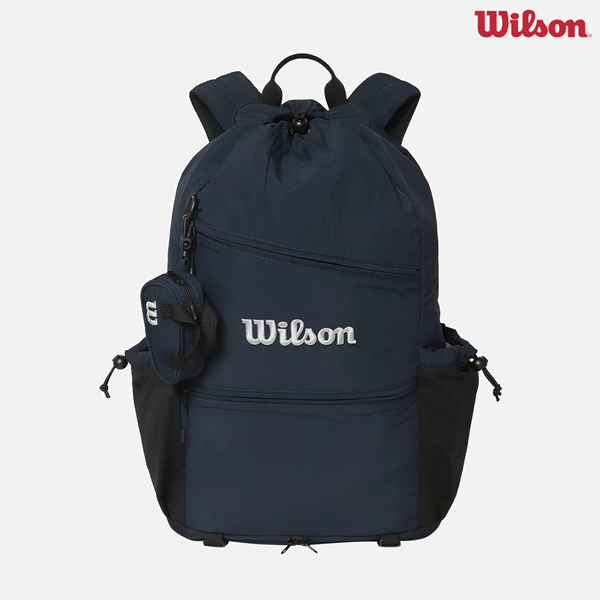

피쳐,🔍 입력 이미지,#1 앤더슨벨 aaa425u 유니섹스,#2 [아코크] Insight Cros,#3 [아코크] Glossy Halfm,#4 앤더슨벨 유니섹스 웨스턴 메리제인,#5 [윌슨] 드로우스트링 백팩 V1
카테고리,패션잡화,패션잡화 ✅,패션잡화 ✅,패션잡화 ✅,패션잡화 ✅,스포츠/레져
제품유형,백팩,백팩 ✅,크로스백,크로스백,로퍼,백팩 ✅
컬러,블랙,블랙 ✅,브라운,블랙 ✅,블랙 ✅,"네이비, 블랙 ✅"
재질,나일론,"나일론, 폴리에스터, 금속 ✅",나일론 ✅,인조가죽,"가죽, 금속",폴리에스터
스타일,"스트릿, 캐주얼","스트릿, 아웃도어 ✅","캐주얼, 미니멀 ✅","미니멀, 모던","클래식, 스트릿 ✅","스포티, 캐주얼 ✅"
분위기,"세련된, 활동적인","활동적인, 세련된 ✅","심플한, 편안한","세련된, 심플한 ✅","세련된, 중후한 ✅","활동적인, 심플한 ✅"
패턴,무지,무지 ✅,무지 ✅,무지 ✅,자수,로고
용도,"일상, 외출, 통학","일상, 외출, 여행 ✅","일상, 외출, 여행 ✅","일상, 외출, 여행 ✅","일상, 외출 ✅","운동, 일상, 통학 ✅"
타겟,유니섹스,유니섹스 ✅,유니섹스 ✅,유니섹스 ✅,유니섹스 ✅,유니섹스 ✅
브랜드,-,앤더슨벨,아코크,아코크,앤더슨벨,Wilson


In [52]:
# 데모 3: 패션 백팩 이미지 → 유사 상품 검색
fashion_url = "https://foundryiq-image-gallery.azurewebsites.net/images/2222518068_0_600.jpg"
results_fashion = search_similar_images(fashion_url, top_k=5)

### 데모 4: 외부 이미지(나이키 바람막이) 검색

🔹 이미지 벡터화 중 (AI Vision → 1024D)...
🔹 GPT-5.2 피쳐 추출 중 (선택지 기반)...
   📝 추출 피쳐: 스포츠/레져, 스포츠재킷, 블랙, 폴리에스터, 스포티/미니멀, 활동적인/심플한, 로고, 운동/러닝/일상, 성인여성, 나이키...
🔹 피쳐 텍스트 → Florence 1024D...
🔹 피쳐 텍스트 → text-embedding-3-large 3072D...
🔀 하이브리드 검색 실행 (벡터 3개×20후보 + BM25 → top 5)...



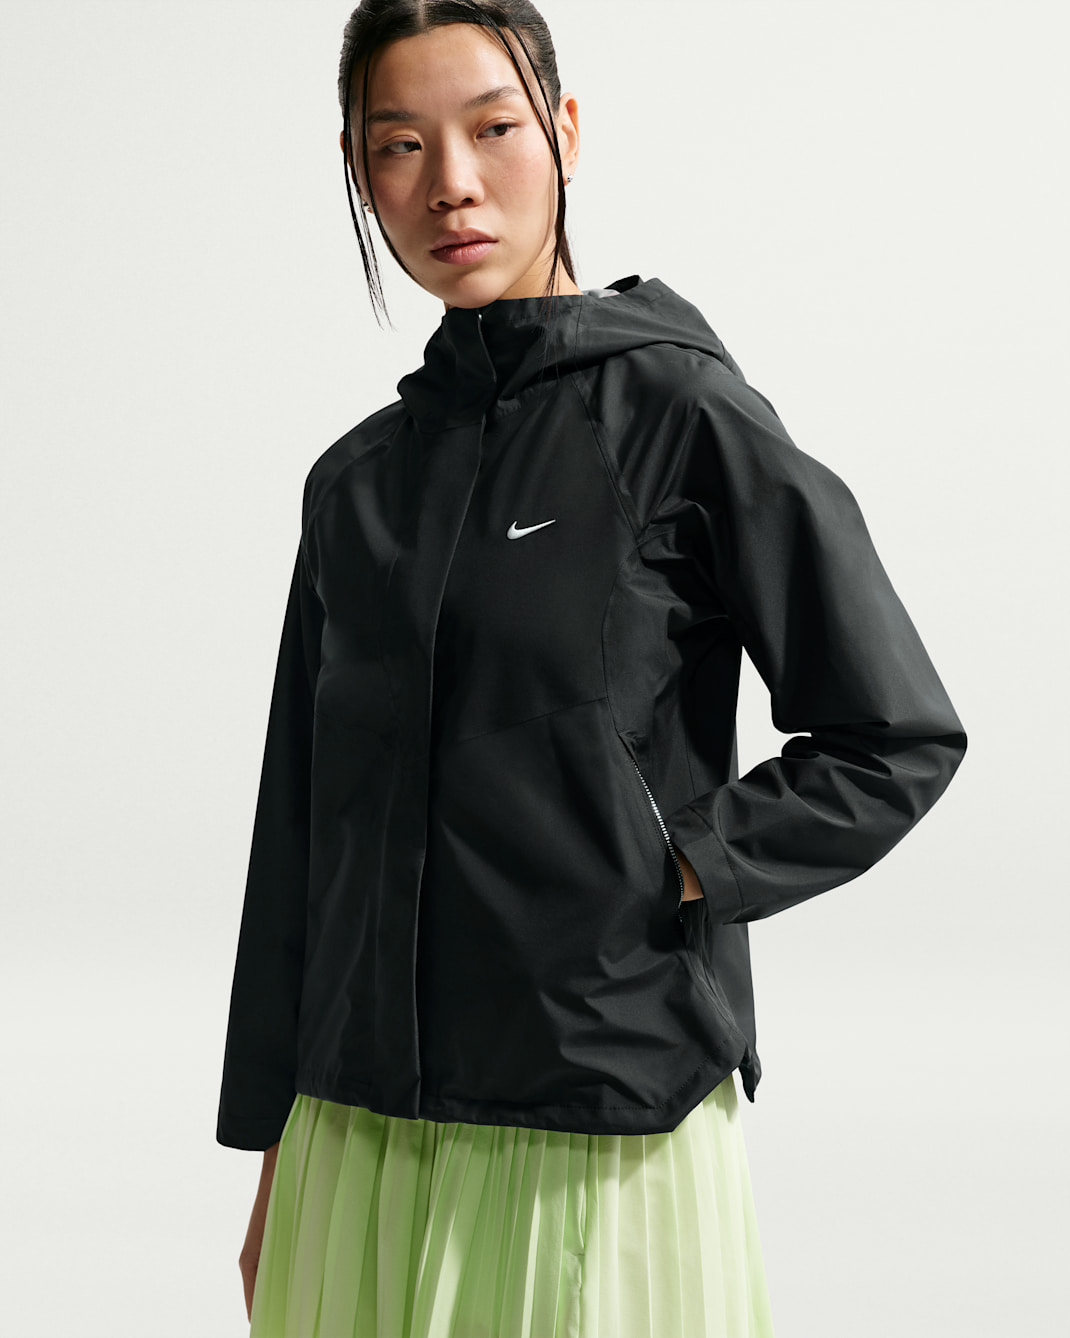
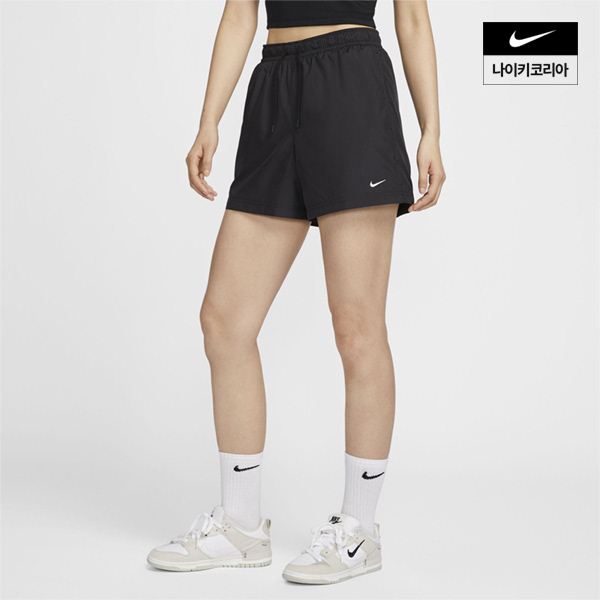
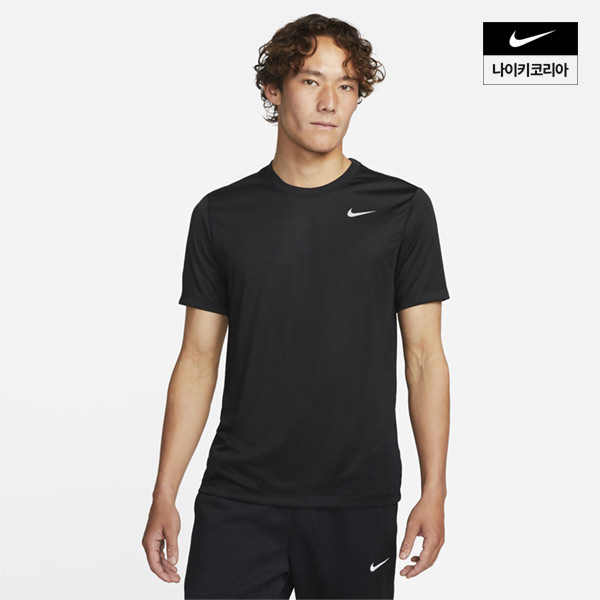
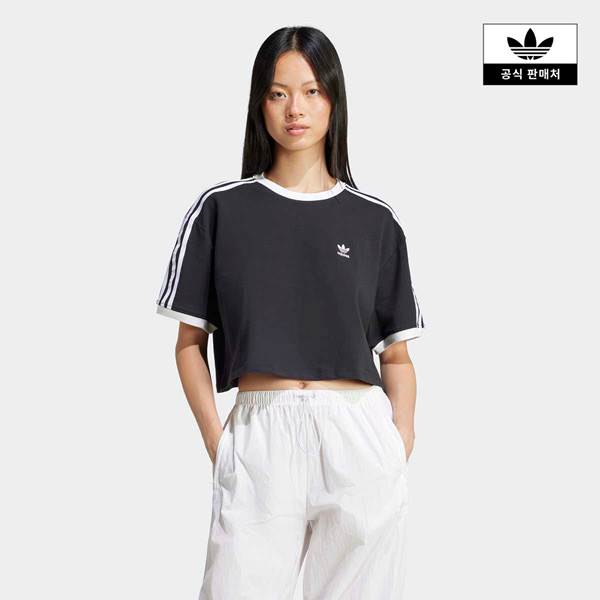
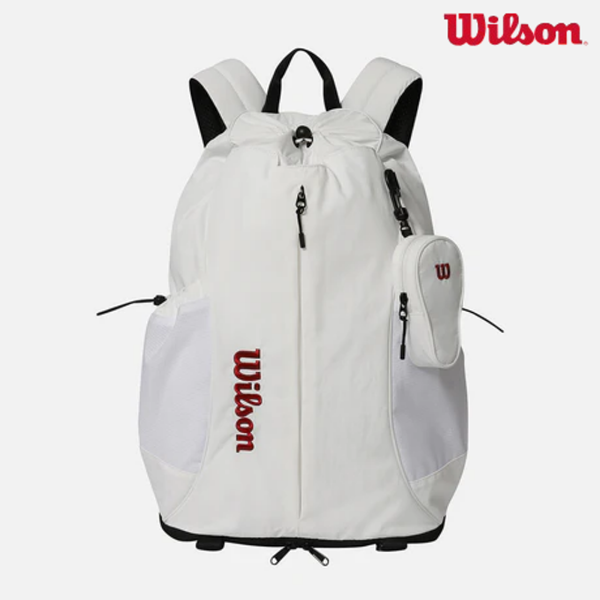
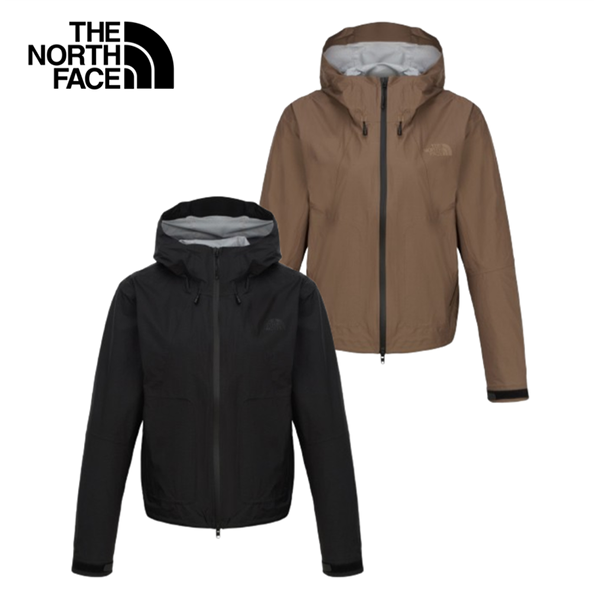

피쳐,🔍 입력 이미지,#1 [나이키] NSW 우븐 여성 MR,#2 [나이키] DF 피트니스 티셔츠,#3 [아디다스코리아공식] JC8149,#4 [윌슨] 드로우스트링 백팩 V2,#5 노스페이스 NJ2HR41 여성 패
카테고리,스포츠/레져,스포츠/레져 ✅,스포츠/레져 ✅,스포츠/레져 ✅,스포츠/레져 ✅,스포츠/레져 ✅
제품유형,스포츠재킷,스포츠반바지,스포츠셔츠,스포츠셔츠,백팩,바람막이
컬러,블랙,"블랙, 화이트 ✅","블랙, 화이트 ✅","블랙, 화이트 ✅","화이트, 레드, 블랙 ✅","블랙, 브라운 ✅"
재질,폴리에스터,폴리에스터 ✅,폴리에스터 ✅,면혼방,폴리에스터 ✅,나일론
스타일,"스포티, 미니멀","스포티, 캐주얼 ✅",스포티 ✅,"스포티, 캐주얼 ✅",스포티 ✅,"아웃도어, 스포티 ✅"
분위기,"활동적인, 심플한","활동적인, 심플한 ✅","심플한, 활동적인 ✅","활동적인, 심플한 ✅","활동적인, 심플한 ✅","활동적인, 세련된 ✅"
패턴,로고,로고 ✅,로고 ✅,로고 ✅,로고 ✅,로고 ✅
용도,"운동, 러닝, 일상","운동, 일상, 외출 ✅","운동, 일상 ✅","운동, 일상, 외출 ✅","운동, 여행, 외출 ✅","등산, 캠핑, 여행"
타겟,성인여성,성인여성 ✅,유니섹스,성인여성 ✅,유니섹스,성인여성 ✅
브랜드,나이키,나이키 ✅,나이키 ✅,아디다스,Wilson,THE NORTH FACE


In [53]:
# 데모 4: 외부 이미지 기반 검색
fashion_url = "https://static.nike.com/a/images/t_web_pdp_535_v2/f_auto/516b2e3f-3753-4baa-a08d-ed6f4df86bfd/AS+W+NK+STRMFT+RAINRNR+JKT.png"
results_fashion = search_similar_images(fashion_url, top_k=5)

### 데모 5: 외부 일반적인 운동화(흰색) 검색

🔹 이미지 벡터화 중 (AI Vision → 1024D)...
🔹 GPT-5.2 피쳐 추출 중 (선택지 기반)...
   📝 추출 피쳐: 패션잡화, 스니커즈, 화이트, 가죽/인조가죽, 캐주얼/스트릿, 세련된/활동적인, 무지, 일상/외출/통학, 유니섹스...
🔹 피쳐 텍스트 → Florence 1024D...
🔹 피쳐 텍스트 → text-embedding-3-large 3072D...
🔀 하이브리드 검색 실행 (벡터 3개×20후보 + BM25 → top 5)...



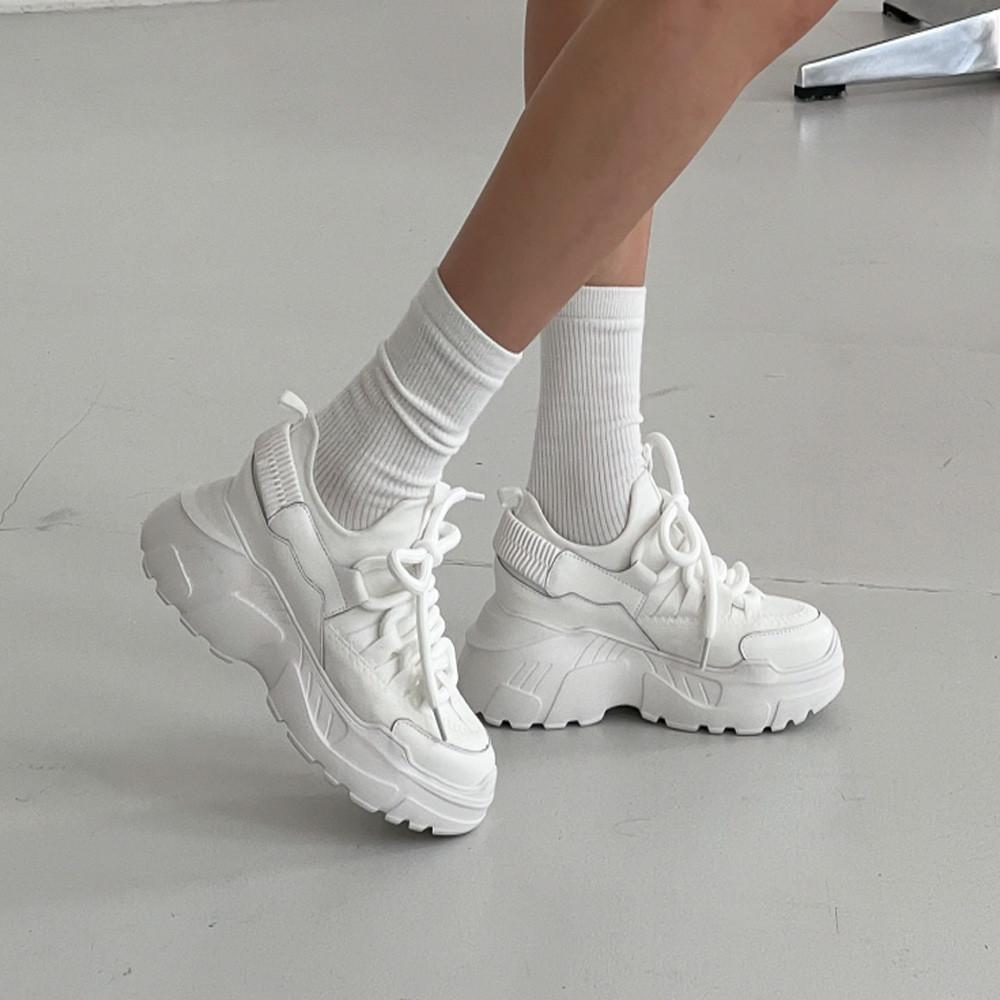
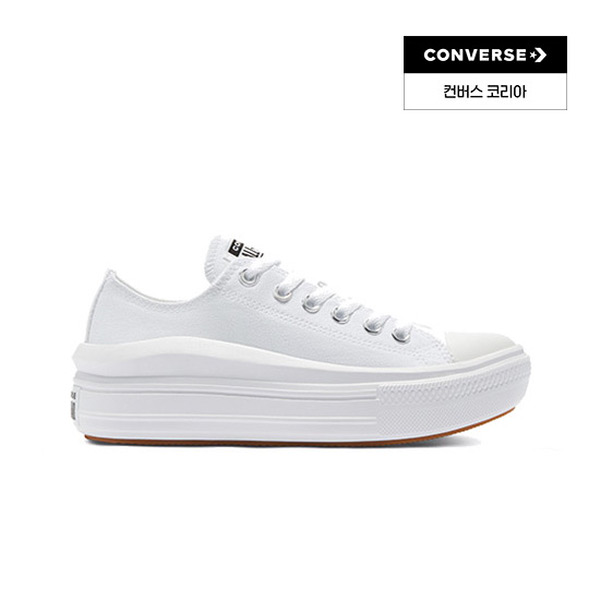
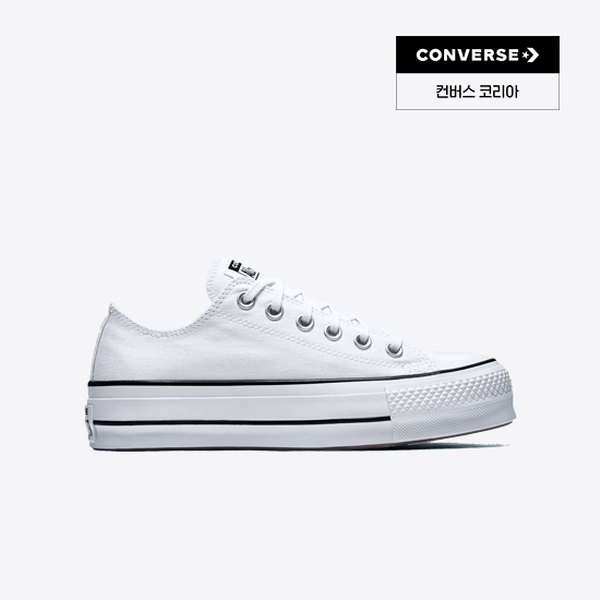
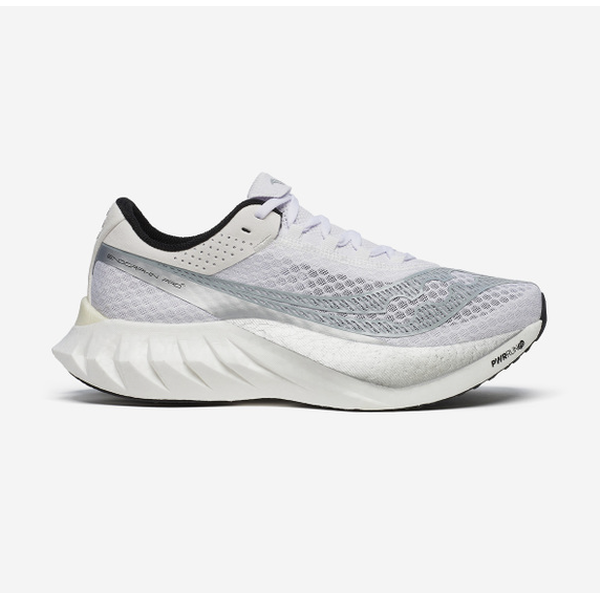
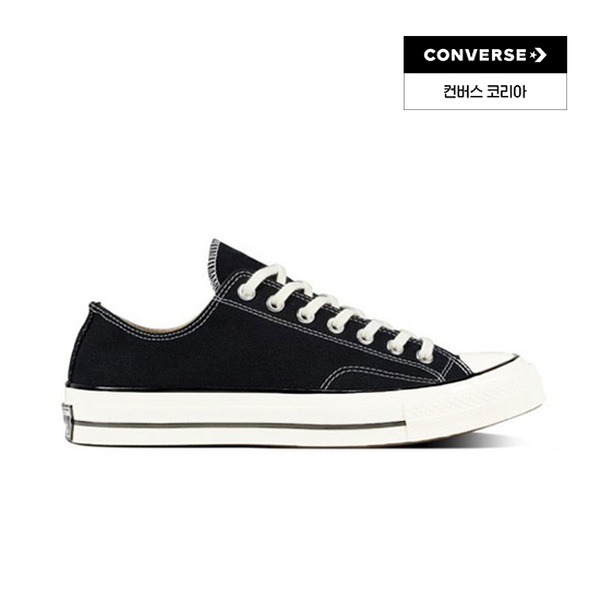
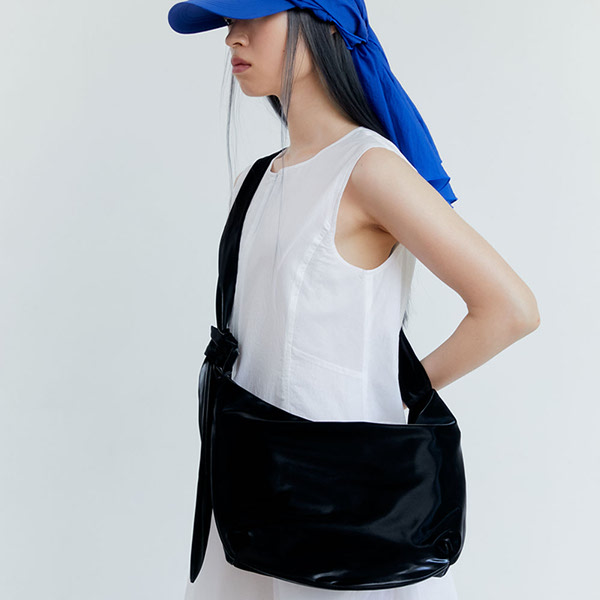

피쳐,🔍 입력 이미지,#1 컨버스 척테일러 올스타 무브 화이,#2 컨버스 척테일러 올스타 리프트 캔,#3 [그랜드스테이지] 써코니 엔돌핀,#4 컨버스 척테일러 1970s 클래식,#5 [아코크] Glossy Halfm
카테고리,패션잡화,스포츠/레져,스포츠/레져,패션잡화 ✅,스포츠/레져,패션잡화 ✅
제품유형,스니커즈,운동화,운동화,스니커즈 ✅,운동화,크로스백
컬러,화이트,화이트 ✅,화이트 ✅,"화이트, 그레이, 블랙 ✅","블랙, 화이트 ✅",블랙
재질,"가죽, 인조가죽","면혼방, 고무","면혼방, 고무","메쉬, 폴리에스터","면혼방, 고무",인조가죽 ✅
스타일,"캐주얼, 스트릿","캐주얼, 스포티 ✅","캐주얼, 스포티 ✅",스포티,"캐주얼, 클래식 ✅","미니멀, 모던"
분위기,"세련된, 활동적인","심플한, 활동적인 ✅","심플한, 단정한","활동적인, 세련된 ✅","심플한, 세련된 ✅","세련된, 심플한 ✅"
패턴,무지,무지 ✅,무지 ✅,무지 ✅,무지 ✅,무지 ✅
용도,"일상, 외출, 통학","일상, 외출, 운동 ✅","일상, 외출, 통학 ✅","운동, 러닝, 일상 ✅","일상, 외출, 통학 ✅","일상, 외출, 여행 ✅"
타겟,유니섹스,유니섹스 ✅,유니섹스 ✅,유니섹스 ✅,유니섹스 ✅,유니섹스 ✅
브랜드,-,컨버스,CONVERSE,써코니,CONVERSE,아코크


In [55]:
# 데모 5: 외부 이미지 기반 검색
fashion_url = "https://www.wishbucket.io/_next/image?url=https%3A%2F%2Fd2gfz7wkiigkmv.cloudfront.net%2Fpickin%2F2%2F1%2F2%2FoThSq-93R7qr_qy6yppo1g&w=1080&q=75"
results_fashion = search_similar_images(fashion_url, top_k=5)

---
## 📊 PoC 정리

### 검색 전략 — 4-way 하이브리드

| 경로 | 입력 | 임베딩 모델 | 검색 필드 | 차원 | 역할 |
|------|------|------------|----------|------|------|
| 경로 1 | 이미지 픽셀 | Azure AI Vision Florence | `image_vector` | 1024D | 시각적 유사도 — 색상, 형태, 디자인 |
| 경로 2 | 피쳐 텍스트 | Azure AI Vision Florence | `feature_text_vector` | 1024D | 시각-의미 크로스모달 (이미지↔텍스트 같은 공간) |
| 경로 3 | 피쳐 텍스트 | text-embedding-3-large | `feature_text_vector_3072` | 3072D | 텍스트 의미 유사도 — 용도, 소재, 스타일 |
| 경로 4 | 피쳐 텍스트 | BM25 키워드 | `title`, `brand` 등 | - | 키워드 매칭 — 브랜드명, 제품 유형 |

> 💡 Florence 1024D는 이미지↔텍스트 크로스모달에 강하고, OpenAI 3072D는 텍스트 간 의미 유사도에 강합니다.  
> 두 모델을 동시에 사용하면 **시각적 유사 + 의미적 유사**를 모두 잡을 수 있습니다.

### 핵심 설계 원칙

1. **4-way 하이브리드**: 이미지 벡터 + Florence 텍스트 벡터 + OpenAI 텍스트 벡터 + BM25 → RRF 통합
2. **듀얼 텍스트 벡터**: 같은 피쳐 텍스트를 Florence(1024D)와 OpenAI(3072D) 두 모델로 임베딩 → 서로 다른 강점 결합
3. **넓은 후보 풀**: `k_nearest_neighbors=20` → 각 벡터 경로에서 20개 후보를 가져와 RRF로 최적 5개 선별
4. **판단 근거 제공**: `structured_features` 피쳐 비교 테이블로 왜 유사한지 항목별 설명 (✅ 매칭 강조)

---

### 🛒 리테일 시나리오별 검색 품질 예측

실제 리테일 환경에서 발생하는 이미지 입력 유형별로, 이 PoC의 검색 정확도가 어떻게 달라지는지 정리합니다.

#### 시나리오 A: 카탈로그/상품 상세 이미지 (클린 배경)
```
📸 흰 배경에 상품만 촬영된 이미지 (e.g. 쇼핑몰 상세 이미지)
→ 정확도: ★★★★★
→ 4개 경로 모두 상품만 인식. 이상적 입력.
```

#### 시나리오 B: 모델 착용 사진 (패션 룩북)
```
📸 모델이 점퍼를 입고 있는 전신 사진
→ 정확도: ★★★★☆
→ 경로 1(이미지 벡터): 사람 + 점퍼 혼합 임베딩 → 점퍼가 아닌 "사람 사진"에 끌릴 수 있음
→ 경로 2~4(피쳐 경로): GPT가 "점퍼, 블랙, 나일론소재"를 정확히 식별 → 상품 기반 검색
→ RRF 통합: 3개 경로가 보완하므로 대체로 정확한 결과.
→ 개선: image_vector weight를 0.8로 낮추면 더 정확해짐
```

#### 시나리오 C: 매장/거리 촬영 (복잡한 배경)
```
📸 매장 진열대에서 찍은 상품 사진, 또는 거리에서 본 옷
→ 정확도: ★★★☆☆
→ 경로 1: 배경 요소(진열대, 간판, 다른 상품)가 벡터에 섞임
→ 경로 2~4: GPT가 주요 상품을 식별하지만, 복수 상품이 있으면 혼동 가능
→ 개선: Grounding DINO 또는 Azure Background Removal로 상품 영역만 크롭 후 임베딩
```

#### 시나리오 D: 여러 상품이 함께 있는 사진 (코디 사진, 세트 상품)
```
📸 가방 + 신발 + 재킷이 함께 있는 코디 사진
→ 정확도: ★★☆☆☆
→ 경로 1: 모든 상품이 하나의 벡터로 압축 → 어떤 상품을 찾는지 알 수 없음
→ 경로 2~4: GPT가 가장 눈에 띄는 상품 하나만 피쳐 추출 (나머지는 무시)
→ 개선: (1) 사용자가 원하는 상품을 크롭해서 입력, (2) 텍스트 힌트와 함께 검색 (예: "이 중에서 가방을 찾아줘")
```

#### 시나리오 E: 경쟁사/타사 웹사이트의 상품 이미지 (디자이너 유스케이스)
```
📸 경쟁사 홈페이지에서 가져온 상품 이미지 URL
→ 정확도: ★★★★★
→ 대부분 클린 배경의 카탈로그 이미지이므로 시나리오 A와 동일
→ 이것이 디자이너의 실제 유스케이스: "경쟁사에서 이런 상품 나왔는데, 우리 쪽에 비슷한 거 있어?"
```

#### 시나리오 F: SNS/인플루언서 이미지 (트렌드 분석)
```
📸 인스타그램에서 본 상품 이미지 (필터, 조명 효과 포함)
→ 정확도: ★★★☆☆
→ 경로 1: 필터/색보정 때문에 색상이 왜곡된 벡터 생성
→ 경로 2~4: GPT가 필터를 무시하고 상품 본질을 파악 → "미니멀, 베이지, 니트"
→ 개선: Florence 모델은 CLIP 기반이라 어느 정도 색상 변형에 강건하지만, 심한 필터는 영향
```

| 시나리오 | 입력 예시 | 예상 정확도 | 핵심 경로 | 개선 포인트 |
|---------|----------|:---:|----------|-----------|
| A. 카탈로그 이미지 | 쇼핑몰 상세 이미지 | ★★★★★ | 4개 경로 모두 | 이상적 → 개선 불필요 |
| B. 모델 착용 사진 | 패션 룩북, 착용샷 | ★★★★☆ | 경로 2~4 우세 | image_vector weight 낮추기 |
| C. 매장/거리 촬영 | 진열대, 거리 사진 | ★★★☆☆ | 경로 2~4 | 배경 제거 전처리 추가 |
| D. 복수 상품 사진 | 코디 사진, 세트 | ★★☆☆☆ | 경로 2~4 (부분적) | 크롭 또는 텍스트 힌트 |
| E. 경쟁사 이미지 | 타사 웹사이트 | ★★★★★ | 4개 경로 모두 | 디자이너 핵심 유스케이스 |
| F. SNS 이미지 | 인스타그램, 필터 적용 | ★★★☆☆ | 경로 2~4 | GPT 피쳐 추출이 필터 보정 |

---

### ⚠️ 유의사항 — 이미지 벡터(경로 1)의 한계

**경로 1(`image_vector`)은 이미지 전체를 임베딩합니다.** 이는 아래와 같은 상황에서 정확도에 영향을 줄 수 있습니다:

| 상황 | 문제 | 영향 |
|------|------|------|
| 모델이 점퍼를 입고 있는 사진 | 이미지 벡터에 **사람 + 배경 + 점퍼**가 모두 포함됨 | 점퍼가 아닌 "사람이 서있는 사진"에 가까운 결과를 끌어올 수 있음 |
| 복잡한 배경의 상품 사진 | 배경 요소(가구, 소품 등)가 벡터에 섞임 | 배경이 유사한 다른 카테고리 상품이 결과에 포함될 수 있음 |
| 여러 상품이 함께 있는 사진 | 모든 상품이 하나의 벡터로 압축 | 어떤 상품을 찾는지 구분 불가 |

**현재 PoC에서의 보완 구조:**

이 문제는 **경로 2, 3, 4가 보완**합니다. GPT-5.2가 이미지를 보고 **상품만 식별**하여 피쳐를 추출합니다 (예: "이건 점퍼다, 아웃도어 스타일, 블랙, 나일론소재"). 이 피쳐 텍스트가 경로 2(Florence 1024D), 경로 3(OpenAI 3072D), 경로 4(BM25)에 반영되므로, 4개 경로 중 3개는 이미 **"상품"을 정확히 찾고 있습니다.**

```
경로 1 (image_vector)  → 사람 + 배경 + 점퍼 (노이즈 포함)  weight=1.5
경로 2 (Florence 1024D) → "점퍼, 블랙, 나일론, 아웃도어" (상품만)  weight=1.0
경로 3 (OpenAI 3072D)   → "점퍼, 블랙, 나일론, 아웃도어" (상품만)  weight=1.0
경로 4 (BM25)           → "점퍼, 블랙, 나일론, 아웃도어" (상품만)
→ RRF 통합: 3개 경로가 "점퍼"를 가리키므로 최종 결과는 점퍼가 우세
```

**프로덕션에서 추가 고려할 수 있는 개선:**

| 방법 | 설명 | 효과 | 복잡도 |
|------|------|------|--------|
| **가중치 조절** | `image_vector weight`를 1.5 → 0.8로 낮춤 | 배경/사람 영향 즉시 감소 | 낮음 (파라미터만 변경) |
| **Grounding DINO** | 오픈소스 모델로 텍스트 프롬프트("jacket") 기반 상품 bbox 크롭 후 임베딩 | 상품만 정확히 추출 (COCO mAP ~52) | 중간 (로컬 GPU 필요) |
| **Azure AI Vision Background Removal** | Azure API로 배경 제거 후 전경(상품) 이미지만 임베딩 | 배경 노이즈 제거. API 호출만으로 간단 | 낮음 (API 추가) |

> 💡 **이 PoC의 인덱스 데이터는 리테일 카탈로그 이미지**(클린 배경, 상품만 촬영)이므로 인덱싱 시에는 문제가 크지 않습니다.  
> 문제가 되는 것은 **검색 시 입력 이미지**입니다. 위 시나리오 B~D, F처럼 복잡한 이미지가 입력될 때 개선이 필요합니다.

---

### PoC 결론

- ✅ 이미지만으로 유사 상품 검색 가능 (구글/네이버 이미지 검색과 동일한 UX)
- ✅ 이미지 벡터 + GPT 피쳐 추출 + **듀얼 텍스트 임베딩** 결합으로 정확도 극대화
- ✅ `structured_features` 기반 투명한 판단 근거 제공
- ✅ Azure AI Search의 Multi-vector RRF + BM25로 검색 품질 커스터마이징 가능
- ✅ 카탈로그 이미지 & 경쟁사 이미지(시나리오 A, E) → 최고 정확도
- ⚠️ 모델 착용/매장/SNS 사진(시나리오 B, C, F) → 피쳐 경로가 보완하지만, 프로덕션에서는 전처리 추가 권장
- ⚠️ 복수 상품 사진(시나리오 D) → 상품 크롭 또는 텍스트 힌트 필요

---

### 🏗️ 프로덕션 자동화 파이프라인 아키텍처 (스케줄 기반)

Blob Storage에 이미지가 업로드되면, AI Search Indexer가 주기적으로 변경을 감지하고 Custom Skill(Azure Function)을 통해 자동으로 인덱스 문서를 생성합니다.

![파이프라인 아키텍처](https://mermaid.ink/img/Zmxvd2NoYXJ0IExSCiAgICBzdWJncmFwaCBCTE9CW0F6dXJlIEJsb2IgU3RvcmFnZV0KICAgICAgICBBW0ltYWdlICsgTWV0YWRhdGFdCiAgICBlbmQKICAgIHN1YmdyYXBoIFNFQVJDSFtBenVyZSBBSSBTZWFyY2hdCiAgICAgICAgQltJbmRleGVyIC0gU2NoZWR1bGUgUFQ1TV0KICAgICAgICBDW1NraWxsc2V0IC0gQ3VzdG9tIFdlYiBBUEkgU2tpbGxdCiAgICAgICAgRFtJbmRleF0KICAgIGVuZAogICAgc3ViZ3JhcGggRlVOQ1tBenVyZSBGdW5jdGlvbl0KICAgICAgICBFWzEudmVjdG9yaXplSW1hZ2UgMTAyNEQKMi5HUFQtNS4yIEZlYXR1cmUgSlNPTgozLnZlY3Rvcml6ZVRleHQgMTAyNEQKNC5lbWJlZGRpbmcgMzA3MkRdCiAgICBlbmQKICAgIHN1YmdyYXBoIEFJW0FJIFNlcnZpY2VzXQogICAgICAgIEZbQXp1cmUgQUkgVmlzaW9uIEZsb3JlbmNlXQogICAgICAgIEdbQXp1cmUgT3BlbkFJIEdQVC01LjIgKyBFbWJlZGRpbmddCiAgICBlbmQKICAgIEEgLS0-fFBvbGwgZXZlcnkgNW1pbnwgQgogICAgQiAtLT58TmV3IGJsb2J8IEMKICAgIEMgLS0-fEhUVFAgUE9TVHwgRlVOQwogICAgRlVOQyAtLT58ZW5yaWNoZWQgZmllbGRzfCBDCiAgICBDIC0tPnxPdXRwdXQgTWFwcGluZ3N8IEQKICAgIEUgLS4tPiBGCiAgICBFIC0uLT4gRwogICAgc3R5bGUgQkxPQiBmaWxsOiNlM2YyZmQsc3Ryb2tlOiMxNTY1YzAsY29sb3I6IzAwMAogICAgc3R5bGUgU0VBUkNIIGZpbGw6I2ZmZjNlMCxzdHJva2U6I2U2NTEwMCxjb2xvcjojMDAwCiAgICBzdHlsZSBGVU5DIGZpbGw6I2U4ZjVlOSxzdHJva2U6IzJlN2QzMixjb2xvcjojMDAwCiAgICBzdHlsZSBBSSBmaWxsOiNmM2U1ZjUsc3Ryb2tlOiM2YTFiOWEsY29sb3I6IzAwMA==)

| 단계 | 컴포넌트 | 역할 |
|------|---------|------|
| 1 | **Blob Storage** | 이미지 + 메타데이터(title, category) 저장소 |
| 2 | **Indexer** (스케줄) | 5분마다 Blob 변경 감지 → Skillset 실행 트리거 |
| 3 | **Skillset** (Custom Web API Skill) | Azure Function에 HTTP POST로 이미지+메타 전달 |
| 4 | **Azure Function** | PoC 4단계 로직 수행 (이미지벡터 + 피쳐추출 + 텍스트벡터 2종) |
| 5 | **Index** | Output Field Mappings로 enriched fields 자동 매핑 |

> 💡 **즉시 반영이 필요한 경우**: Event Grid → Azure Function → `Run Indexer` REST API 호출 패턴을 추가하면 됩니다.

## 🧹 Cleanup (선택사항)

PoC 인덱스를 삭제하려면 아래 셀의 주석을 해제하고 실행하세요.

In [54]:
# PoC 인덱스 삭제 (주석 해제 후 실행)
# index_client.delete_index(POC_INDEX_NAME)
# print(f"🗑️  PoC 인덱스 '{POC_INDEX_NAME}' 삭제 완료")